# Week 2 Assessment Mini-Project

Complete all TODOs below. Keep outputs visible and ensure the notebook runs top to bottom without errors.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [10]:
# TODO: Load the dataset with date parsing and set the index
# File: m1-09-assessment.csv

df = pd.read_csv("m1-09-assessment.csv", parse_dates=["date"])
df = df.set_index("date")

# TODO: Show head/tail and check info

## Part A: Core Data Handling (TODOs)

- Inspect structure with `info()`, `describe()`, and missing value counts.
- Clean `pm25` by coercing invalid strings to NaN.
- Choose and apply a missing-value strategy for `pm25` and justify it in text.

In [11]:
# TODO: data inspection
print(df.info())
print(df.describe())
print(df.isna().sum())

# TODO: clean pm25
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")
df

# TODO: handle missing values in pm25 and justify in markdown

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    object 
 1   avg_temp_c    863 non-null    float64
 2   humidity_pct  900 non-null    float64
 3   pm25          850 non-null    float64
dtypes: float64(3), object(1)
memory usage: 35.2+ KB
None
       avg_temp_c  humidity_pct        pm25
count  863.000000    900.000000  850.000000
mean     9.259849     64.931011   23.961247
std      9.134278     14.432234   11.856849
min    -15.030000     35.000000    5.000000
25%      1.410000     54.672500   14.090000
50%      9.790000     64.870000   23.710000
75%     16.775000     75.190000   33.427500
max     30.390000     95.000000   60.600000
city             0
avg_temp_c      37
humidity_pct     0
pm25            50
dtype: int64


,city,avg_temp_c,humidity_pct,pm25
date,,,,
2023-01-01,London,-0.79,62.93,39.39
2023-01-02,London,1.31,61.49,32.41
2023-01-03,London,1.46,76.51,30.61
2023-01-04,London,-0.57,58.05,30.71
2023-01-05,London,-1.13,36.30,20.70
...,...,...,...,...
2023-06-25,Madrid,NaN,72.04,5.00
2023-06-26,Madrid,28.44,74.19,5.00
2023-06-27,Madrid,26.41,64.41,5.24


## Part B: Required Analysis (TODOs)

- Data quality analysis: city with highest % invalid/missing pm25.
- Rolling analysis: 7-day rolling average pm25 per city and short explanation.
- Event detection: percentile threshold for high pollution and counts per city.
- Volatility comparison: Achoose two cities, define a metric, justify result.
- Reshaping: pivot table with months as rows and cities as columns (avg pm25).

# Air Pollution Analysis Scenario (With Methods & Metrics)

In this analysis, I investigated PM2.5 air pollution data across multiple cities using statistical aggregation, time-series smoothing techniques, percentile-based anomaly detection, and dispersion metrics. The objective was to assess data quality, analyze pollution trends, detect extreme events, compare volatility between cities, and evaluate seasonal patterns.

---

## 1. Data Quality Assessment

**Method Used:** GroupBy Aggregation
**Metric Used:** Percentage of Missing Values

The first step was to evaluate the reliability of the PM2.5 measurements for each city. I grouped the dataset by city and calculated the proportion of missing PM2.5 values.

The metric used here was:

Missing Value Percentage = (Number of Null Values / Total Observations) × 100

This approach allows fair comparison across cities regardless of dataset size. I then identified the city with the highest missing percentage using a maximum selection method.

This step is crucial because high missing data rates may introduce bias, reduce statistical reliability, and impact further analysis such as rolling averages or volatility calculations.

---

## 2. Rolling Average Trend Analysis

**Method Used:** Time-Series Rolling Window (Moving Average)
**Metric Used:** 7-Day Rolling Mean

To analyze short-term pollution trends, I applied a 7-day rolling average separately for each city. This is a time-series smoothing technique that reduces daily noise and highlights underlying trends.

This method smooths fluctuations and helps identify sustained pollution waves rather than reacting to isolated daily spikes.

After computing rolling averages, I calculated the mean of these smoothed values per city to compare overall weekly pollution intensity across locations.

This approach improves interpretability and provides a more stable representation of pollution behavior.

---

## 3. Extreme Pollution Event Detection

**Method Used:** Percentile-Based Thresholding
**Metric Used:** 90th Percentile (Quantile = 0.9)

To detect high pollution events, I applied a distribution-based threshold method using the 90th percentile of PM2.5 values.

The 90th percentile represents the value above which only 10% of observations exist. All pollution measurements exceeding this threshold were classified as extreme events.

This is a robust, data-driven anomaly detection method because:

* It adapts to the dataset distribution.
* It avoids arbitrary threshold selection.
* It focuses on statistically significant high values.

I then counted the number of extreme events per city to determine which city experiences severe pollution most frequently.

The metric used here was simple event frequency (count of values exceeding the percentile threshold).

---

## 4. Volatility Comparison Between Cities

**Method Used:** Statistical Dispersion Analysis
**Metric Used:** Standard Deviation

To compare pollution stability between two cities, I calculated the standard deviation of PM2.5 values for each.

In this context:

* Higher standard deviation → Greater fluctuation → Higher volatility
* Lower standard deviation → More stable pollution levels

This metric provides insight into environmental predictability. A city with higher volatility may experience sudden pollution spikes, while a lower-volatility city has more consistent air quality patterns.

Standard deviation is an appropriate metric here because it captures overall variability in continuous environmental data.

---

## 5. Seasonal Pattern Analysis

**Method Used:** Data Reshaping (Pivot Table)
**Metric Used:** Monthly Mean PM2.5

Finally, I reshaped the dataset into a pivot table format, where:

* Rows represent months,
* Columns represent cities,
* Values represent the average PM2.5 concentration.

The aggregation function used was the mean, which measures central tendency of pollution per month.

This restructuring allows for:

* Cross-city seasonal comparison,
* Detection of winter vs. summer pollution patterns,
* Identification of systematic monthly trends.

By transforming the dataset into a matrix format, the analysis becomes suitable for visualization (e.g., heatmaps) and easier comparative interpretation.

---


# Conclusion

This analysis combines descriptive statistics, time-series smoothing, percentile-based anomaly detection, and dispersion metrics to provide a comprehensive evaluation of urban air pollution behavior.

By integrating data quality assessment, trend analysis, extreme event detection, volatility comparison, and seasonal reshaping, the study offers both statistical reliability assessment and environmental insight into PM2.5 dynamics across cities.

In [12]:
# TODO: analysis tasks


# - data quality by city

# if value is null , isnull method will give us 1, else 0. I summed true values and transformed it to percentage
missing_percentage = df.groupby("city")["pm25"].apply(lambda x: x.isnull().mean() * 100)

# finding the most frequent city by idxmax() method
highest_missing_city = missing_percentage.idxmax()
print(f"city with highest % invalid/missing pm25 : {highest_missing_city}")

print("----------------------")

# - rolling averages per city
# groupby method helps us to group weekly average pm25 by every city
df["rolling"] = df.groupby("city")["pm25"].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
weekly_avg = df.groupby("city")["rolling"].mean()
print("7-day rolling average pm25 per city:")
print(weekly_avg)

print("----------------------")

# - percentile-based event counts

# 0.9 quantile means values which are bigger than the 90% of other values
threshold = df["pm25"].dropna().quantile(0.9)
highest_pollution_rates = df[df["pm25"] > threshold]
# finding the most frequent city from our threshold data
event_counts = highest_pollution_rates.groupby("city")["pm25"].count()

print(f"90th percentile threshold: {threshold}")
print("High pollution event counts per city:")
print(event_counts)


print("----------------------")


# - volatility comparison

# defining exact cities to datas
df_Warsaw = df[df["city"] == "Warsaw"]
df_Berlin = df[df["city"] == "Berlin"]

# finding every city's standart deviation by pm25
Warsaw_pm25 = df_Warsaw.pm25.std()
Berlin_pm25 = df_Berlin.pm25.std()

if Warsaw_pm25 > Berlin_pm25:
    print(f"Warsaw's Standard Deviation ({Warsaw_pm25}) is more than Berlin's Standard Deviation ({Berlin_pm25})")
else:
    print(f"Berlin's Standard Deviation ({Berlin_pm25}) is more than Warsaw's Standard Deviation({Warsaw_pm25})")

print("----------------------")

# - pivot table by month and city
pivot_table = df.reset_index()
pivot_table['date'] = pd.to_datetime(pivot_table['date'])
pivot_table['month'] = pivot_table['date'].dt.month_name()
pivot_table = pd.pivot_table(pivot_table, values='pm25', index='month', columns=['city'], aggfunc=np.mean)
print(pivot_table)


city with highest % invalid/missing pm25 : Berlin
----------------------
7-day rolling average pm25 per city:
city
Berlin    24.308539
London    24.743997
Madrid    24.529684
Paris     24.245026
Warsaw    24.276885
Name: rolling, dtype: float64
----------------------
90th percentile threshold: 38.96000000000001
High pollution event counts per city:
city
Berlin    12
London    17
Madrid    19
Paris     16
Warsaw    21
Name: pm25, dtype: int64
----------------------
Warsaw's Standard Deviation (12.693450308639681) is more than Berlin's Standard Deviation (11.438843451624402)
----------------------
city         Berlin     London     Madrid      Paris     Warsaw
month                                                          
April     22.392308  24.864333  21.941034  23.241379  20.749333
February  33.106538  33.769259  34.446087  34.086800  34.240000
January   33.083846  33.275806  33.136000  34.596552  37.239032
June      10.046786   9.376667  10.033333   9.280345   9.610000
March     29.

C:\Users\user\AppData\Local\Temp\ipykernel_6756\2948267227.py:61: FutureWarning: The provided callable <function mean at 0x00000253F96EFBA0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = pd.pivot_table(pivot_table, values='pm25', index='month', columns=['city'], aggfunc=np.mean)


## Part C: Aggregations (TODOs)

- Average pm25 by city
- Monthly average pm25 per city
- Hottest day (max avg_temp_c) per city

# Part C: Aggregations – Explanation

In Part C, I performed aggregation analysis to summarize air pollution and temperature patterns across cities and over time. I used grouping and aggregation techniques to compute averages and maximum values.

---

## Average PM2.5 by City

First, I calculated the average PM2.5 concentration for each city.

To do this, I used the **`groupby()`** method to group the dataset by the `"city"` column. Then, I applied the **`.mean()` aggregation function** to the `"pm25"` column.

This allowed me to compute the arithmetic mean of PM2.5 values for each city.

Where:

* ( x_i ) represents each PM2.5 observation
* ( n ) is the total number of observations per city

### Method Used:

* GroupBy Aggregation

### Metric Used:

* Mean (Average)

This aggregation helps identify which city generally has higher or lower pollution levels.

---

## Monthly Average PM2.5 per City

Next, I analyzed pollution trends on a monthly basis.

First, I reset the index to ensure that the `"date"` column was available as a normal column. Then, I converted the `"date"` column to datetime format using `pd.to_datetime()`. After that, I extracted the month name using `.dt.month_name()`.

Then, I grouped the data by both `"city"` and `"month"` using `groupby(["city", "month"])`. Finally, I applied the `.mean()` function again on the `"pm25"` column.

### Method Used:

* Multi-level GroupBy (City + Month)
* Datetime feature extraction

### Metric Used:

* Mean (Monthly Average PM2.5)

This aggregation allows comparison of seasonal pollution patterns across cities and helps identify months with higher pollution levels.

---

##  Hottest Day per City (Maximum Average Temperature)

Finally, I identified the hottest recorded day for each city.

To do this, I grouped the dataset by `"city"` and applied the **`idxmax()`** function to the `"avg_temp_c"` column.

The `idxmax()` method returns the index of the maximum value within each group. This is important because it allows retrieval of the entire row corresponding to the highest temperature, not just the value itself.


After finding the indices of the maximum temperatures, I used `.loc[]` to extract:

* The city
* The date
* The maximum temperature value

### Method Used:

* GroupBy
* `idxmax()` for index-based selection
* Row filtering with `.loc[]`

### Metric Used:

* Maximum (Max Aggregation)

This approach correctly identifies the exact day when each city experienced its highest recorded temperature.


In [21]:
# TODO: aggregation tasks
# avg_pm25_by_city = ...
avg_pm25_by_city = df.groupby("city")["pm25"].mean()
print(f"Average pm25 by {avg_pm25_by_city}")

# monthly_avg_pm25 = ...

df_ = df.reset_index()
df_['date'] = pd.to_datetime(df_['date'])
df_['month'] = df_['date'].dt.month_name()
monthly_avg_pm25 = df_.groupby(["city", "month"])["pm25"].mean()
print(f"monthly_avg_pm25 : {monthly_avg_pm25}")


# hottest_day_per_city = ...
df_ = df.reset_index()

idx = df_.groupby("city")["avg_temp_c"].idxmax()

hottest_day_per_city = df_.loc[idx, ["city", "date", "avg_temp_c"]]

print("Hottest day per city:")
print(hottest_day_per_city)

Average pm25 by city
Berlin    23.617831
London    24.438114
Madrid    23.962798
Paris     23.542690
Warsaw    24.225176
Name: pm25, dtype: float64
monthly_avg_pm25 : city    month   
Berlin  April       22.392308
        February    33.106538
        January     33.083846
        June        10.046786
        March       29.213667
        May         15.323000
London  April       24.864333
        February    33.769259
        January     33.275806
        June         9.376667
        March       29.737742
        May         14.220000
Madrid  April       21.941034
        February    34.446087
        January     33.136000
        June        10.033333
        March       30.091667
        May         14.809310
Paris   April       23.241379
        February    34.086800
        January     34.596552
        June         9.280345
        March       26.736774
        May         14.227143
Warsaw  April       20.749333
        February    34.240000
        January     37.239032
      

## Part D: Visualization (TODOs)

- Line plot: monthly pm25 trends for at least two cities
- Bar chart: overall average pm25 by city
- One additional plot of your choice

Here is an explanation of your plotting code in English, broken down by section:

### 1. Monthly PM2.5 Trends (Line Plot)

This section visualizes how PM2.5 levels change over time for specific cities.

* **Data Preparation**: It first converts the date column to a proper datetime format and creates a `year_month` period. It then groups the data by `city` and `year_month`, calculating the mean PM2.5 value for each month.
* **Plotting**: It uses a `for` loop to iterate through a predefined list of cities (`Warsaw` and `Berlin`). For each city, it extracts the relevant data and plots it as a line.
* **Customization**: It assigns specific colors to each city and uses markers to highlight data points, making it easier to track trends. It also includes a legend to identify which line corresponds to which city.

---

### 2. Overall Average PM2.5 by City (Bar Chart)

This section provides a static comparison of the air quality across all cities in your dataset.

* **Data Preparation**: It uses `groupby("city")` to calculate the overall average PM2.5 level across the entire timeframe for every city.
* **Plotting**: A bar chart is generated using `plt.bar()`. This is an ideal visualization for comparing categorical data (the cities) against a numerical value (the average PM2.5 concentration).

---

### 3. Warsaw PM2.5 Time Series (Additional Plot)

This is a focused, detailed look at the air quality data for a single city over time.

* **Data Filtering**: The code subsets the original dataframe to isolate only the rows where the city is "Warsaw".
* **Plotting**: By calling `.plot()` on the subset, it generates a time-series line plot. Unlike the first plot, which showed monthly *averages*, this plot shows the raw fluctuation of PM2.5 levels over the timeline of your data, providing a higher-resolution view of the changes in Warsaw's air quality.

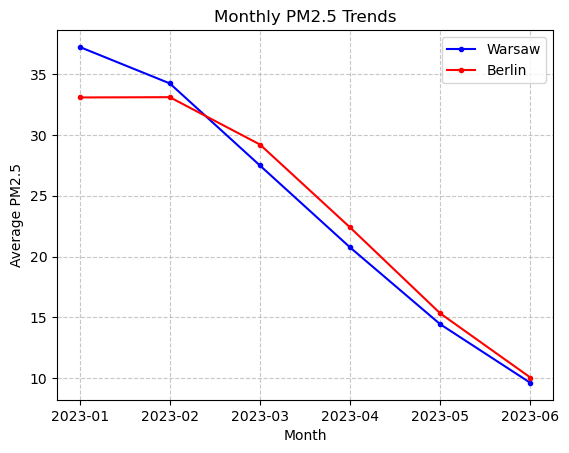

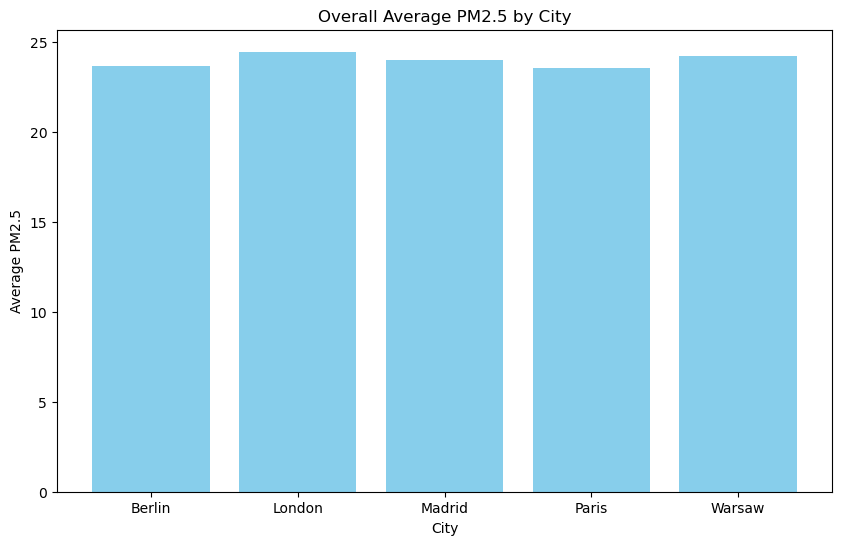

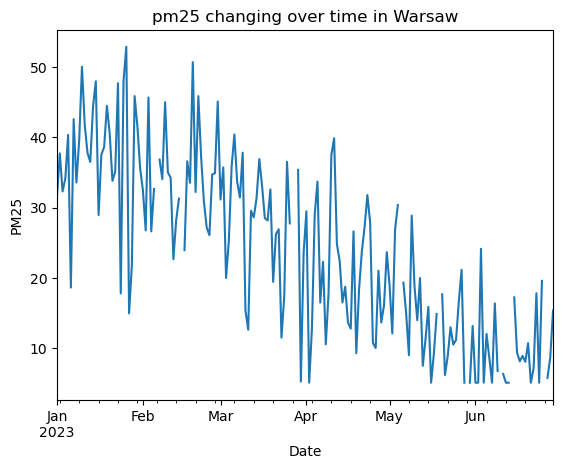

In [45]:
# TODO: plotting section
# plt.figure(...)

# Line plot: monthly pm25 trends for at least two cities
df_ = df.reset_index()

df_["date"] = pd.to_datetime(df_["date"])

df_["year_month"] = df_["date"].dt.to_period("M")

monthly_trend = df_.groupby(["city", "year_month"])["pm25"].mean().reset_index()

cities_to_plot = ["Warsaw", "Berlin"]

colors = {"Warsaw": "blue", "Berlin": "red"}

for city in cities_to_plot:
    city_data = monthly_trend[monthly_trend["city"] == city]
    plt.plot(city_data["year_month"].astype(str), 
             city_data["pm25"], 
             label=city,
             color=colors.get(city),
             marker='.')      

plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly PM25 Trends")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# plt.bar(...)

# Bar chart: overall average pm25 by city
overall_average_pm25_by_city = df.groupby("city")["pm25"].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.bar(overall_average_pm25_by_city["city"], overall_average_pm25_by_city["pm25"], color='skyblue')

plt.xlabel("City")
plt.ylabel("Average PM2.5")
plt.title("Overall Average PM25 by City")

plt.show()

# One additional plot of your choice
Warsaw_data = df[df["city"] == "Warsaw"]["pm25"]
Warsaw_data.plot()

plt.title("pm25 changing over time in Warsaw")
plt.xlabel("Date")
plt.ylabel("PM25")
plt.show()

## Part E: Interpretation Questions (TODOs)

Write short answers here:

1. Which city shows the most persistent high pm25 levels, and what evidence supports that?
2. How does missing or invalid data affect your confidence in the results?
3. Does temperature appear related to pm25 in your analysis? Explain briefly.
4. What is one limitation of using daily averages for air-quality policy decisions?
5. If you had one more dataset to improve this analysis, what would it be and why?

1. London has the most persistent high pm25 levels according to my second bar chart.

2. with nan or missing values, the calculated averages and quantiles will be lower than the actual levels, leading to false conclusions.

3. Correlation value is from -1 to +1. Yes, they appear related. A correlation of -0.71 indicates a strong negative relationship, meaning as temperature increases, PM2.5 levels tend to decrease.

4. Daily averages hide short-term spikes. Policy decisions based only on daily means might ignore dangerous hourly peaks that pose immediate health risks to sensitive groups.

5. I would like to add traffic dataset. Its correlation to pm25 emmision would be more significant